In [1]:
from torchsummary import summary
import reinforcement
import models
import networks
import gymnasium as gym
import torch
import ale_py
import time
import utils

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = False)
s, _ = env.reset()

env.states = env.observation_space.shape[0]
env.actions = env.action_space.shape[0]

#actor = networks.Mu(env.states, env.actions)
#critic = networks.CQ(env.states, env.actions)

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [400, 200])
critic = models.MLP((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [400, 200])

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 1000, verbose=1, checkpoint=50)


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 finished with reward -93.62496185302734 in 86 steps and 0.166592 time, Total steps: 87
Actor loss: 0, Critic loss: 0, Total steps: 87
Episode 1 finished with reward -97.88150024414062 in 83 steps and 0.116400 time, Total steps: 171
Actor loss: 0, Critic loss: 0, Total steps: 171
Episode 2 finished with reward -97.85478210449219 in 72 steps and 0.111050 time, Total steps: 244
Actor loss: 0, Critic loss: 0, Total steps: 244
Episode 3 finished with reward -120.15863800048828 in 833 steps and 1.766354 time, Total steps: 1078
Actor loss: 0.008082657050388523, Critic loss: 28.0740865508118, Total steps: 1078
Episode 4 finished with reward -115.77000427246094 in 142 steps and 1.272142 time, Total steps: 1221
Actor loss: 0.06815244520483604, Critic loss: 18.332292934834072, Total steps: 1221
Episode 5 finished with reward -116.46327209472656 in 136 steps and 1.135486 time, Total steps: 1358
Actor loss: -0.0387370494418662, Critic loss: 16.06143457284809, Total steps: 1358
Episode 6 f

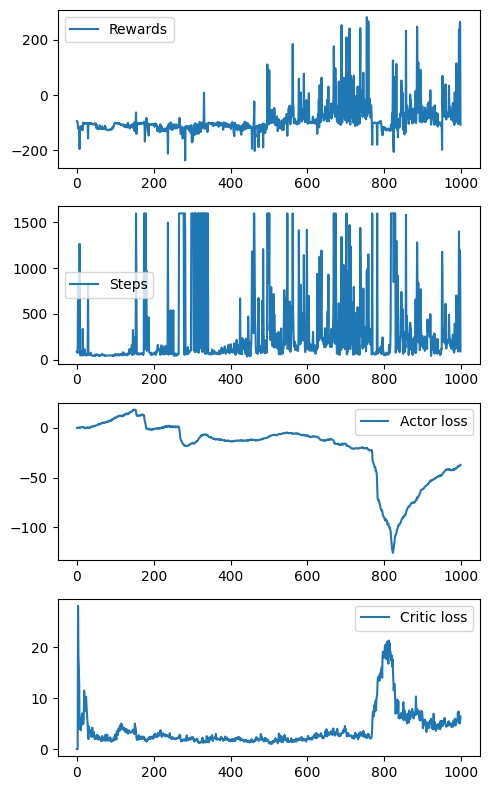

In [3]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(4, figsize=(5, 8))
ax[0].plot(rewards, label='Rewards')
ax[1].plot(steps, label='Steps')
ax[2].plot(actor_loss, label='Actor loss')  
ax[3].plot(critic_loss, label='Critic loss')  

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

plt.tight_layout()
plt.show()

In [4]:
#actor.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/models/actor_ep1000.pth"))
#critic.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/models/critic_ep1000.pth"))

env = gym.make("BipedalWalker-v3", hardcore = False, render_mode = "rgb_array")

#video_folder = "agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/videos"
video_folder = "temp/"
utils.record_model(env, actor, video_folder, "ep1000")

c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\hss19\Documents\GitHub\ml-2025\mlc\reinforcement\temp folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode finished. Total reward: 264.9915466308594
